# Intake Triage Bot
This notebook contains a real intake triage workflow for helpdesk, clinic, or service center requests. The agent is designed to:

- classify incoming requests into real queues,
- determine urgency,
- ask for missing required intake information,
- route or escalate when needed,
- and produce a full ticket summary for handoff.

In [1]:
import sys
from pathlib import Path

# Make the repo root importable from this notebook folder.
repo_root = Path.cwd().parent
sys.path.append(str(repo_root))

In [2]:
from intake_triage_agent import IntakeTriageAgent

agent = IntakeTriageAgent()
print("Intake Triage Agent ready.")

Intake Triage Agent ready.


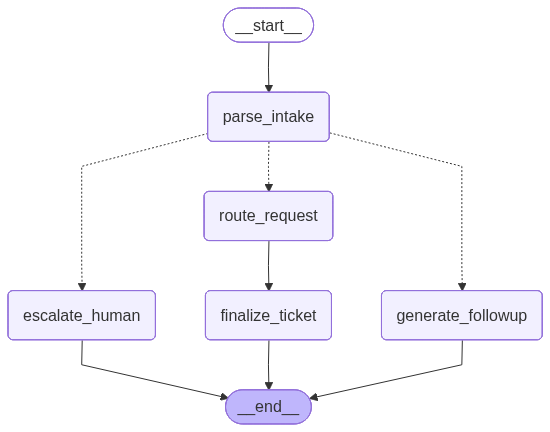

In [3]:
agent.workflow

## Example intake flow
Use the agent with an incoming request. If the intake is missing required details, the agent will ask for more information.

In [ ]:
initial_request = """
Hi, our account is locked and the customer can't access the billing portal. They say payment failed but they didn't provide an account number.
Please help us resolve this quickly.
"""
result = agent.process(initial_request)
result

## Handling follow-up questions
If the agent requests missing information, provide the answer and run the agent again with the `follow_up_answer` field.

In [ ]:
if result.get("follow_up_question"):
    print("Agent follow-up question:", result["follow_up_question"])
    follow_up_answer = "The customer is Jane Doe and she can be reached at jane.doe@example.com."
    final = agent.process(initial_request, follow_up_answer=follow_up_answer)
    final
else:
    print("No follow-up needed.")

## Local deployment
The deployable app is in `app.py` at the repository root. Run:

```powershell
python -m uvicorn app:app --reload --host 0.0.0.0 --port 8000
```

Then open `http://localhost:8000` to use the intake bot via browser.

## Why this problem?
Real support and clinical teams waste time reading raw messages, guessing urgency, and chasing missing contact or case details. A triage agent reduces repeated handoffs by classifying, routing, and collecting missing intake information before a ticket is created.

## What the agent does
- Extracts request summary, category, urgency, customer name, and contact details.
- Detects missing required intake fields and generates a follow-up question.
- Flags out-of-scope requests for human review.
- Routes requests to the right team queue and creates a ready-to-use ticket summary.